## 关联分析

测量一个项与另外一个项之间共现的强度。不是通过预测发生（如，分类和回归），而是在项的共现中，以易于识别的**规则**发现数据中隐藏的**模式**。

关联算法广泛应用于零售分析，推荐引擎和垮网页的在线点击流分析等。

生活中的示例：纸尿裤和啤酒


### 挖掘关键规则
1. 准备交易格式的数据
2. 列出经常出现的项集。支持度、置信度、提升度、确信度
3. 从项集生成相关的关联规则。查找所有频繁项集、从频繁项集中提取规则

### Apriori算法
利用格子项集上的一些简单逻辑原理来减少要测试的项集数量

### 频繁模式增长算法
使用频繁模式树(FP-Tree)的特殊图形数据结构压缩事务记录。

*学习路径*

## 1. 核心思想：从“购物篮”说起
最经典的例子是 “啤酒与尿布”：

在美国超市，发现爸爸们买尿布时，有较大概率也会买啤酒。

这不是预测“谁买尿布”，而是发现“尿布 → 啤酒”这个规则。

关联分析的目标就是找到类似：

{牛奶} → {面包}

{手机, 充电器} → {手机壳}

这样的强规则。

## 2. 核心术语（必须理解）
假设有交易记录：

|交易ID|购买项|
|---|------|
|1|牛奶, 面包, 尿布v
|2|面包, 黄油|
|3|牛奶, 尿布, 啤酒|
|4|牛奶, 面包, 尿布, 啤酒|

针对规则：{牛奶, 尿布} → {啤酒}

### (1) 支持度 (Support)
项集 {牛奶, 尿布} 出现的概率

Support(A) = 包含A的交易数 / 总交易数

例：{牛奶, 尿布} 出现在交易1、3、4 → 3/4 = 0.75

### (2) 置信度 (Confidence)
买了A的情况下，也买B的条件概率

Confidence(A→B) = Support(A∪B) / Support(A)

例：包含{牛奶, 尿布}的交易有3次，其中同时有啤酒的是交易3、4 → 2/3 ≈ 0.67

### (3) 提升度 (Lift)
看A的出现是否促进B的出现

Lift(A→B) = Confidence(A→B) / Support(B)

Lift > 1 → 正相关

Lift = 1 → 独立

Lift < 1 → 负相关

支持度用来砍掉低频模式（没意义），
置信度衡量规则强度，
提升度避免“买面包也买水”这种看似强但实际是水本身热销的误导。

## 3. 关键算法：Apriori（先验算法）

核心原理： 一个项集要成为频繁项集，它的所有子集也必须频繁。

反过来说： 如果一个子集不频繁（支持度低），那么包含它的任何超集也不用计算了。

步骤示例
设定最小支持度 = 0.5

1. 生成1-项集：
牛奶(3/4=0.75) ✔
面包(3/4=0.75) ✔
尿布(3/4=0.75) ✔
啤酒(2/4=0.5) ✔
黄油(1/4=0.25) ✗

2. 生成2-项集（只用频繁1-项集组合）：
{牛奶,面包}(2/4=0.5) ✔
{牛奶,尿布}(3/4=0.75) ✔
{牛奶,啤酒}(2/4=0.5) ✔
{面包,尿布}(2/4=0.5) ✔
{面包,啤酒}(1/4=0.25) ✗
{尿布,啤酒}(2/4=0.5) ✔

3. 生成3-项集（只从频繁2-项集且前k-1项相同组合）：
{牛奶,尿布,啤酒}：先看{牛奶,尿布}、{牛奶,啤酒}、{尿布,啤酒}都频繁 → 可以计算
出现2次 → 0.5 ✔

4. 生成所有可能的规则（如{牛奶,尿布}→{啤酒}）并计算置信度、提升度。

## 4 常见误区与注意事项

不是因果关系：{尿布}→{啤酒} 不是“尿布导致买啤酒”，仅是相关。

高置信度 ≠ 好规则：必须看提升度，否则会被热销商品误导。

支持度阈值设太高：会漏掉稀有但有趣的模式（如昂贵商品）。

数据稀疏时：Apriori 可能很慢 → 改用 FP-Growth（不需要生成候选项集）。


## 5 下一步学习建议（按顺序）

用纸笔手动计算一次：用上面的4条交易数据，算支持度、置信度、提升度。

用Python跑一次Apriori：把数据换成自己的CSV（如电商销售记录）。

理解FP-Growth思想：比Apriori快，面试常问。

了解闭频繁项集 / 极大频繁项集：压缩输出规模。

尝试序列模式挖掘（GSP, PrefixSpan）：考虑时间顺序，如“先买手机 → 两周后买手机壳”。

In [2]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# 交易数据
dataset = [['牛奶','面包','尿布'],
           ['面包','黄油'],
           ['牛奶','尿布','啤酒'],
           ['牛奶','面包','尿布','啤酒']]

te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)

# 找频繁项集（支持度>=0.5）
frequent_itemsets = apriori(df, min_support=0.5, use_colnames=True)

# 生成关联规则（置信度>=0.6）
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

print(rules[['antecedents','consequents','support','confidence','lift']])

print("\n（lift > 1 的规则才有意义）。")

            antecedents          consequents  support  confidence      lift
0       frozenset({尿布})      frozenset({啤酒})     0.50    0.666667  1.333333
1       frozenset({啤酒})      frozenset({尿布})     0.50    1.000000  1.333333
2       frozenset({啤酒})      frozenset({牛奶})     0.50    1.000000  1.333333
3       frozenset({牛奶})      frozenset({啤酒})     0.50    0.666667  1.333333
4       frozenset({尿布})      frozenset({牛奶})     0.75    1.000000  1.333333
5       frozenset({牛奶})      frozenset({尿布})     0.75    1.000000  1.333333
6       frozenset({尿布})      frozenset({面包})     0.50    0.666667  0.888889
7       frozenset({面包})      frozenset({尿布})     0.50    0.666667  0.888889
8       frozenset({牛奶})      frozenset({面包})     0.50    0.666667  0.888889
9       frozenset({面包})      frozenset({牛奶})     0.50    0.666667  0.888889
10  frozenset({尿布, 啤酒})      frozenset({牛奶})     0.50    1.000000  1.333333
11  frozenset({尿布, 牛奶})      frozenset({啤酒})     0.50    0.666667  1.333333
12  frozense

In [4]:
# sample from amazon

# 使用Python直接下载
import pandas as pd
import requests

# SNAP官方数据链接
url = "https://snap.stanford.edu/data/amazon-meta.txt.gz"
# 或者使用预处理后的CSV版本（见下方完整代码）

Amazon产品共购关联分析项目
正在加载数据...

【数据探索】
交易记录数: 15
唯一商品数: 18
平均每笔交易商品数: 3.00
最长交易: 4个商品
最短交易: 2个商品


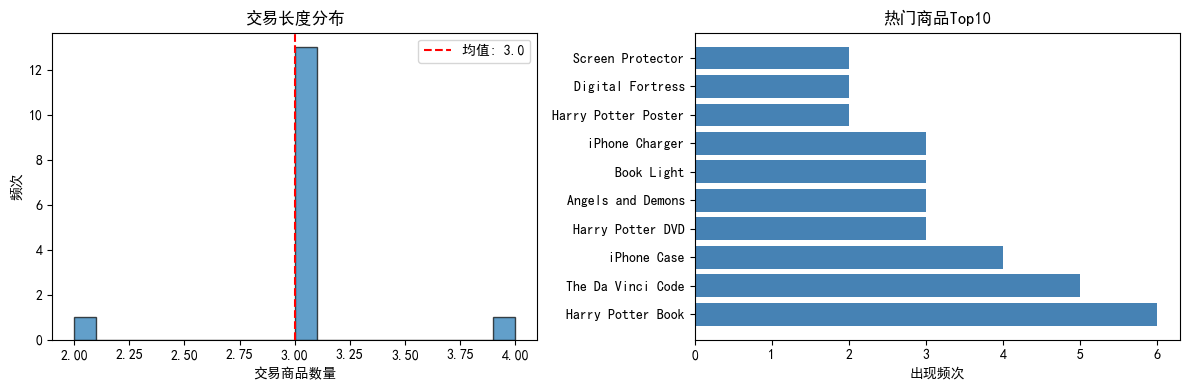


【数据编码】
总商品数: 18
支持度阈值 0.03 下，保留商品数: 18/18

【频繁项集挖掘】
找到 62 个频繁项集

支持度分布:
count    62.000000
mean      0.117204
std       0.066869
min       0.066667
25%       0.066667
50%       0.133333
75%       0.133333
max       0.400000
Name: support, dtype: float64

支持度最高的Top10项集:
  [Harry Potter Book] → 支持度: 0.4000
  [The Da Vinci Code] → 支持度: 0.3333
  [iPhone Case] → 支持度: 0.2667
  [Angels and Demons] → 支持度: 0.2000
  [Book Light] → 支持度: 0.2000
  [Harry Potter DVD] → 支持度: 0.2000
  [iPhone Charger] → 支持度: 0.2000
  [The Da Vinci Code, Book Light] → 支持度: 0.2000
  [iPhone Case, iPhone Charger] → 支持度: 0.2000
  [AirPods] → 支持度: 0.1333

【关联规则生成】
生成 137 条关联规则（置信度≥0.3，提升度≥1.0）

指标统计:
  置信度范围: [0.333, 1.000]
  提升度范围: [1.000, 7.500]
  规则平均长度: 1.41

【规则可视化】


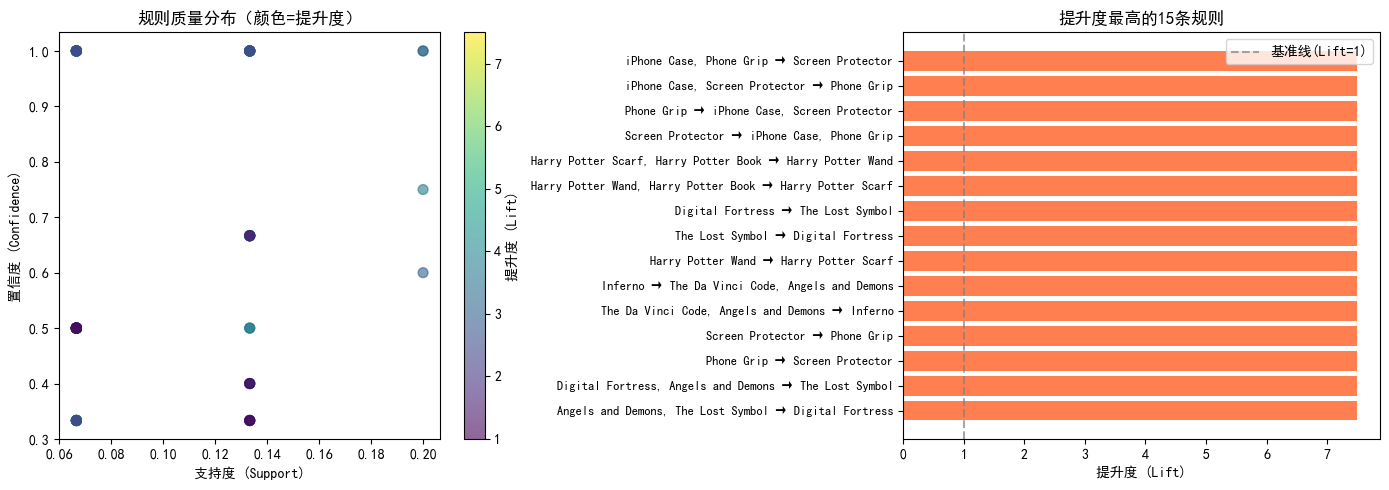


【网络图构建】


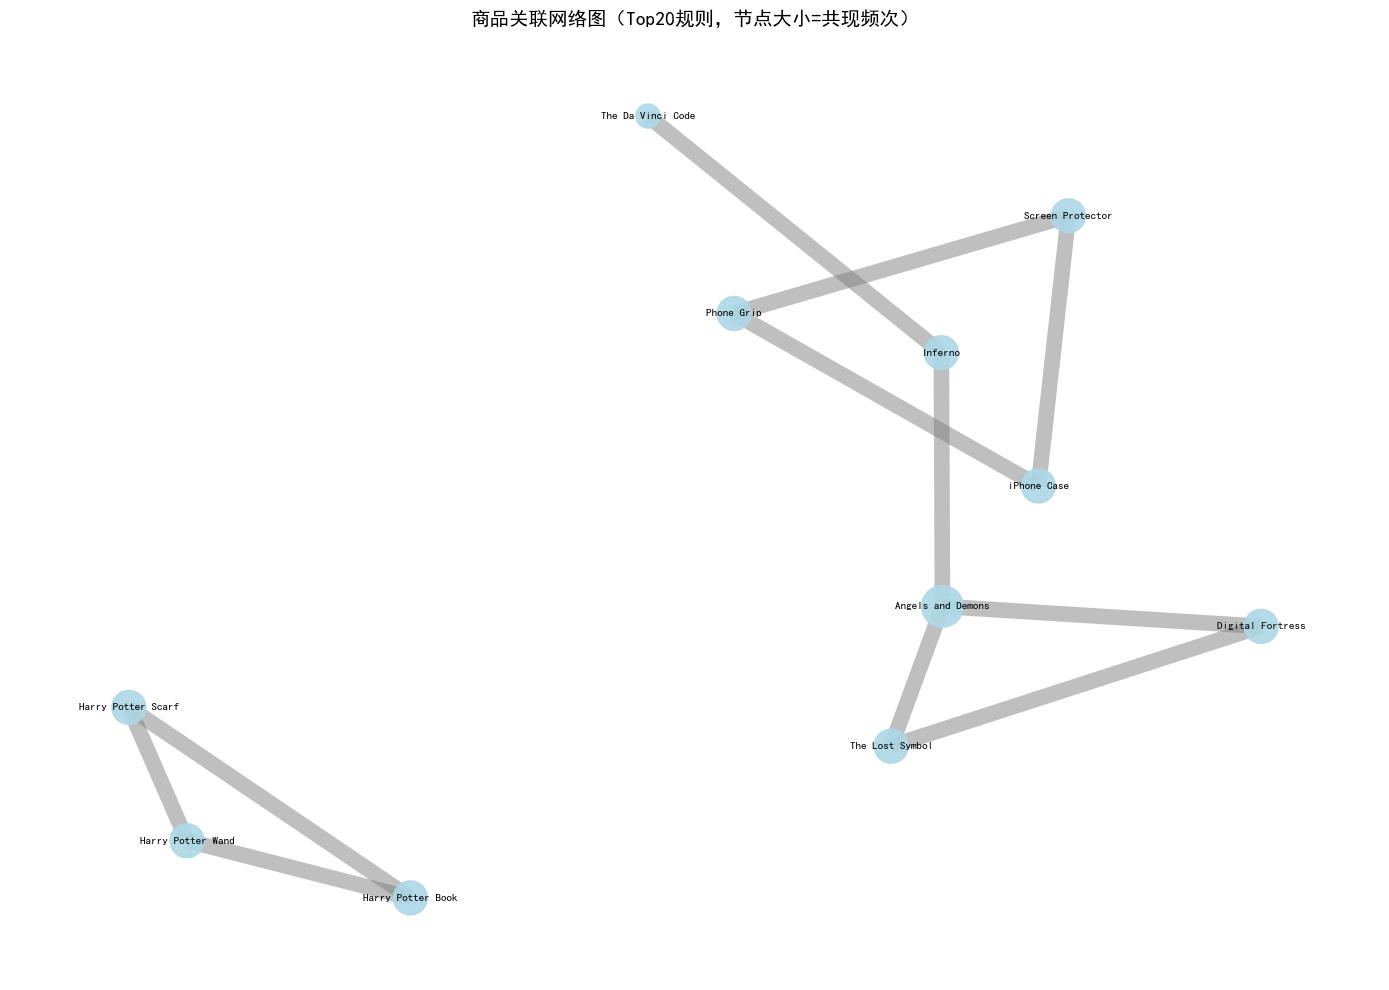


【关键发现】
1. 最强关联规则: Angels and Demons, The Lost Symbol → Digital Fortress
   提升度: 7.50 (远大于1，强正相关)
   置信度: 100.00%

2. 高置信度规则（购买后几乎一定会买另一件）:
   Angels and Demons, The Lost Symbol → Digital Fortress (置信度: 100.00%)
   Phone Grip → Screen Protector (置信度: 100.00%)
   Inferno → The Da Vinci Code, Angels and Demons (置信度: 100.00%)

3. 业务建议:
   • 将提升度>2的规则用于交叉销售推荐
   • 将高置信度规则用于购物车捆绑促销
   • 在商品详情页展示关联商品

规则已导出到 association_rules.csv

项目分析完成！


In [6]:
# ============================================
# 关联分析完整项目：Amazon产品共购挖掘
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from collections import Counter
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("="*60)
print("Amazon产品共购关联分析项目")
print("="*60)

# ============================================
# 第一部分：数据加载与预处理
# ============================================

# 方式1：如果从SNAP下载原始数据，需要解析
# 这里提供模拟数据结构（实际使用时替换为真实数据）
def load_sample_data():
    """
    创建示例交易数据
    在实际项目中，替换为从SNAP数据集解析的真实数据
    """
    # 模拟购物篮数据（每行是一个订单/用户的购买集合）
    transactions = [
        ['Harry Potter Book', 'Harry Potter DVD', 'Harry Potter Poster'],
        ['The Da Vinci Code', 'Angels and Demons', 'Digital Fortress'],
        ['Harry Potter Book', 'The Da Vinci Code', 'Book Light'],
        ['iPhone Charger', 'iPhone Case', 'Screen Protector'],
        ['Harry Potter DVD', 'Harry Potter Book', 'Harry Potter Soundtrack'],
        ['The Da Vinci Code', 'Harry Potter Book', 'Book Light', 'Bookmark'],
        ['iPhone Case', 'iPhone Charger', 'AirPods'],
        ['Digital Fortress', 'Angels and Demons', 'The Lost Symbol'],
        ['Harry Potter Book', 'Harry Potter Poster', 'Harry Potter Wand'],
        ['Screen Protector', 'iPhone Case', 'Phone Grip'],
        ['Book Light', 'The Da Vinci Code', 'Bookmark'],
        ['Harry Potter DVD', 'Harry Potter Soundtrack'],
        ['iPhone Charger', 'AirPods', 'iPhone Case'],
        ['Angels and Demons', 'The Da Vinci Code', 'Inferno'],
        ['Harry Potter Book', 'Harry Potter Wand', 'Harry Potter Scarf'],
    ]
    return transactions

# 用于实际Amazon数据的解析函数
def parse_amazon_meta(file_path):
    """
    解析SNAP Amazon元数据文件
    文件格式示例：
    Id:   1
    ASIN: 0000013714
    title: Pattern Recognition
    group: Book
    salesrank: 12345
    similar: 0000014875 0000020751 0000038257
    """
    transactions = []
    current_product = None
    similar_products = []
    
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if line.startswith('Id:'):
                # 保存上一个产品的共购关系
                if current_product and len(similar_products) > 0:
                    # 每对共购产品形成一个“交易篮”
                    for sim in similar_products:
                        transactions.append([current_product, sim])
                # 重置
                current_product = line.split(':')[1].strip()
                similar_products = []
            elif line.startswith('similar:'):
                # 解析similar列表
                sim_part = line.replace('similar:', '').strip()
                if sim_part:
                    similar_products = sim_part.split()[1:]  # 第一个是计数，跳过
            elif line.startswith('group:'):
                group = line.split(':')[1].strip()
    
    return transactions

# ============================================
# 第二部分：数据探索
# ============================================

def explore_data(transactions):
    """探索性数据分析"""
    print("\n" + "="*60)
    print("【数据探索】")
    print("="*60)
    
    # 基本信息
    n_transactions = len(transactions)
    print(f"交易记录数: {n_transactions}")
    
    # 统计所有商品
    all_items = [item for trans in transactions for item in trans]
    unique_items = set(all_items)
    print(f"唯一商品数: {len(unique_items)}")
    
    # 交易长度分布
    trans_lengths = [len(trans) for trans in transactions]
    print(f"平均每笔交易商品数: {np.mean(trans_lengths):.2f}")
    print(f"最长交易: {max(trans_lengths)}个商品")
    print(f"最短交易: {min(trans_lengths)}个商品")
    
    # 可视化交易长度分布
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 直方图
    axes[0].hist(trans_lengths, bins=20, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('交易商品数量')
    axes[0].set_ylabel('频次')
    axes[0].set_title('交易长度分布')
    axes[0].axvline(np.mean(trans_lengths), color='red', linestyle='--', label=f'均值: {np.mean(trans_lengths):.1f}')
    axes[0].legend()
    
    # 热门商品Top10
    item_counts = Counter(all_items)
    top_items = item_counts.most_common(10)
    items, counts = zip(*top_items)
    axes[1].barh(items, counts, color='steelblue')
    axes[1].set_xlabel('出现频次')
    axes[1].set_title('热门商品Top10')
    
    plt.tight_layout()
    plt.savefig('01_data_exploration.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return item_counts

# ============================================
# 第三部分：One-Hot编码（Apriori输入格式）
# ============================================

def encode_transactions(transactions, min_support_threshold=0.01):
    """将交易数据转换为One-Hot编码矩阵"""
    print("\n" + "="*60)
    print("【数据编码】")
    print("="*60)
    
    # 获取唯一商品列表
    all_items = sorted(set([item for trans in transactions for item in trans]))
    print(f"总商品数: {len(all_items)}")
    
    # 构建One-Hot矩阵
    encoded = []
    for trans in transactions:
        row = [1 if item in trans else 0 for item in all_items]
        encoded.append(row)
    
    df_encoded = pd.DataFrame(encoded, columns=all_items)
    
    # 计算支持度并过滤低频商品
    item_support = df_encoded.mean(axis=0)
    frequent_items = item_support[item_support >= min_support_threshold].index.tolist()
    print(f"支持度阈值 {min_support_threshold} 下，保留商品数: {len(frequent_items)}/{len(all_items)}")
    
    df_filtered = df_encoded[frequent_items]
    
    return df_filtered, frequent_items

# ============================================
# 第四部分：Apriori算法挖掘频繁项集
# ============================================

def mine_frequent_itemsets(df_encoded, min_support=0.05):
    """使用Apriori算法挖掘频繁项集"""
    print("\n" + "="*60)
    print("【频繁项集挖掘】")
    print("="*60)
    
    # 挖掘频繁项集
    frequent_itemsets = apriori(
        df_encoded, 
        min_support=min_support, 
        use_colnames=True,
        max_len=4  # 限制最大项集大小
    )
    
    # 添加项集长度列
    frequent_itemsets['itemset_length'] = frequent_itemsets['itemsets'].apply(len)
    
    print(f"找到 {len(frequent_itemsets)} 个频繁项集")
    print(f"\n支持度分布:")
    print(frequent_itemsets['support'].describe())
    
    # 按支持度排序展示
    print("\n支持度最高的Top10项集:")
    top_itemsets = frequent_itemsets.nlargest(10, 'support')
    for _, row in top_itemsets.iterrows():
        items = ', '.join(list(row['itemsets'])[:3])  # 只显示前3个
        if len(row['itemsets']) > 3:
            items += f"... (+{len(row['itemsets'])-3})"
        print(f"  [{items}] → 支持度: {row['support']:.4f}")
    
    return frequent_itemsets

# ============================================
# 第五部分：生成关联规则
# ============================================

def generate_rules(frequent_itemsets, df_encoded, min_confidence=0.3, min_lift=1.0):
    """从频繁项集生成关联规则"""
    print("\n" + "="*60)
    print("【关联规则生成】")
    print("="*60)
    
    # 生成规则
    rules = association_rules(
        frequent_itemsets, 
        metric="confidence", 
        min_threshold=min_confidence
    )
    
    # 过滤提升度
    rules = rules[rules['lift'] >= min_lift]
    rules = rules.sort_values('lift', ascending=False)
    
    print(f"生成 {len(rules)} 条关联规则（置信度≥{min_confidence}，提升度≥{min_lift}）")
    
    if len(rules) > 0:
        print("\n指标统计:")
        print(f"  置信度范围: [{rules['confidence'].min():.3f}, {rules['confidence'].max():.3f}]")
        print(f"  提升度范围: [{rules['lift'].min():.3f}, {rules['lift'].max():.3f}]")
        print(f"  规则平均长度: {rules['antecedents'].apply(len).mean():.2f}")
    
    return rules

# ============================================
# 第六部分：规则可视化与解读
# ============================================

def visualize_rules(rules, top_n=15):
    """可视化关联规则"""
    if len(rules) == 0:
        print("没有生成足够的规则，请调低阈值")
        return
    
    print("\n" + "="*60)
    print("【规则可视化】")
    print("="*60)
    
    # 图表1: 支持度-置信度-提升度散点图
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 散点图：支持度 vs 置信度（颜色=提升度）
    scatter = axes[0].scatter(
        rules['support'], 
        rules['confidence'], 
        c=rules['lift'], 
        cmap='viridis', 
        alpha=0.6, 
        s=50
    )
    axes[0].set_xlabel('支持度 (Support)')
    axes[0].set_ylabel('置信度 (Confidence)')
    axes[0].set_title('规则质量分布（颜色=提升度）')
    plt.colorbar(scatter, ax=axes[0], label='提升度 (Lift)')
    
    # 柱状图：Top规则按提升度排序
    top_rules = rules.nlargest(top_n, 'lift')
    rule_names = []
    for _, row in top_rules.iterrows():
        ante = ', '.join(list(row['antecedents'])[:2])
        cons = ', '.join(list(row['consequents'])[:2])
        if len(row['antecedents']) > 2:
            ante += '...'
        rule_names.append(f'{ante} → {cons}')
    
    bars = axes[1].barh(range(top_n), top_rules['lift'].values, color='coral')
    axes[1].set_yticks(range(top_n))
    axes[1].set_yticklabels(rule_names, fontsize=9)
    axes[1].set_xlabel('提升度 (Lift)')
    axes[1].set_title(f'提升度最高的{top_n}条规则')
    axes[1].axvline(x=1, color='gray', linestyle='--', alpha=0.7, label='基准线(Lift=1)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('02_rules_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

def network_visualization(rules, top_n=20):
    """网络图可视化：展示商品之间的关联"""
    if len(rules) == 0:
        return
    
    print("\n【网络图构建】")
    
    # 取Top规则构建图
    top_rules = rules.nlargest(top_n, 'lift')
    
    G = nx.Graph()
    
    # 添加节点和边
    edge_weights = {}
    for _, row in top_rules.iterrows():
        for ante in row['antecedents']:
            for cons in row['consequents']:
                if (ante, cons) not in edge_weights:
                    edge_weights[(ante, cons)] = row['lift']
                else:
                    edge_weights[(ante, cons)] = max(edge_weights[(ante, cons)], row['lift'])
                G.add_edge(ante, cons, weight=row['lift'])
    
    # 绘制网络图
    plt.figure(figsize=(14, 10))
    
    # 节点布局
    pos = nx.spring_layout(G, k=2, seed=42)
    
    # 节点大小（基于度数中心性）
    degrees = dict(G.degree())
    node_sizes = [degrees[node] * 300 for node in G.nodes()]
    
    # 边宽度（基于提升度）
    edge_weights_list = [G[u][v]['weight'] * 1.5 for u, v in G.edges()]
    
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue', alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=edge_weights_list, alpha=0.5, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
    
    plt.title(f'商品关联网络图（Top{top_n}规则，节点大小=共现频次）', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('03_network_graph.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 输出关键发现
    print("\n" + "="*60)
    print("【关键发现】")
    print("="*60)
    
    # 找出最强关联（提升度最高）
    best_rule = rules.loc[rules['lift'].idxmax()]
    ante_str = ', '.join(list(best_rule['antecedents'])[:3])
    cons_str = ', '.join(list(best_rule['consequents'])[:3])
    print(f"1. 最强关联规则: {ante_str} → {cons_str}")
    print(f"   提升度: {best_rule['lift']:.2f} (远大于1，强正相关)")
    print(f"   置信度: {best_rule['confidence']:.2%}")
    
    # 高置信度规则
    high_conf = rules[rules['confidence'] > 0.7].nlargest(3, 'confidence')
    if len(high_conf) > 0:
        print(f"\n2. 高置信度规则（购买后几乎一定会买另一件）:")
        for _, row in high_conf.iterrows():
            ante = ', '.join(list(row['antecedents'])[:2])
            cons = ', '.join(list(row['consequents'])[:2])
            print(f"   {ante} → {cons} (置信度: {row['confidence']:.2%})")
    
    # 业务建议
    print("\n3. 业务建议:")
    print("   • 将提升度>2的规则用于交叉销售推荐")
    print("   • 将高置信度规则用于购物车捆绑促销")
    print("   • 在商品详情页展示关联商品")

# ============================================
# 主程序运行
# ============================================

def main():
    """主函数：执行完整分析流程"""
    
    # 1. 加载数据
    print("正在加载数据...")
    transactions = load_sample_data()  # 替换为parse_amazon_meta('amazon-meta.txt')
    
    # 2. 探索数据
    item_counts = explore_data(transactions)
    
    # 3. 编码数据
    df_encoded, frequent_items = encode_transactions(transactions, min_support_threshold=0.03)
    
    # 4. 挖掘频繁项集（根据数据规模调整支持度）
    # 小数据集用0.05，大数据集用更小的值
    min_support = 0.05 if len(transactions) < 1000 else 0.01
    frequent_itemsets = mine_frequent_itemsets(df_encoded, min_support=min_support)
    
    # 5. 生成关联规则
    rules = generate_rules(frequent_itemsets, df_encoded, min_confidence=0.3, min_lift=1.0)
    
    # 6. 可视化
    if len(rules) > 0:
        visualize_rules(rules, top_n=15)
        network_visualization(rules, top_n=20)
        
        # 导出规则到CSV
        rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_csv(
            'association_rules.csv', index=False, encoding='utf-8-sig'
        )
        print("\n规则已导出到 association_rules.csv")
    else:
        print("\n⚠️ 未生成任何规则，尝试降低 min_confidence 或 min_support 阈值")
    
    print("\n" + "="*60)
    print("项目分析完成！")
    print("="*60)

if __name__ == "__main__":
    main()

Amazon Product Co-Purchasing Network - 关联分析项目

[1/4] 正在解析Amazon元数据...
文件路径: I:/app-data/amazon-meta.txt.gz


解析进度: 15010574it [00:23, 625698.53it/s]



解析完成！
  产品总数: 379093
  共购关系对数: 1788725

[2/4] 数据探索分析

📊 产品类别分布:
  Book: 278,773 个产品 (73.5%)
  Music: 64,141 个产品 (16.9%)
  Video: 18,242 个产品 (4.8%)
  DVD: 17,924 个产品 (4.7%)
  Toy: 7 个产品 (0.0%)
  Software: 3 个产品 (0.0%)
  Video Games: 1 个产品 (0.0%)
  Baby Product: 1 个产品 (0.0%)
  Sports: 1 个产品 (0.0%)

📈 销量排名统计 (Salesrank，数值越小越畅销):
  最低(最畅销): -1
  最高(最不畅销): 3,126,234
  中位数: 193,908

🌟 最畅销产品Top10:
  1. [-1] Mortal Stakes...
  2. [-1] Powerful Potions of Santeria...
  3. [-1] Kennedy's Pocket Guide to Working With Executive R...
  4. [-1] I Forgot, Honey, Why Are We Democrats?...
  5. [0] How to Start and Run Your Own Mystery Shopping Com...
  6. [0] How To Get The Best Creative Work From Your Agency...
  7. [0] Help Me Talk Right: How to Teach a Child to Say th...
  8. [0] Gods on Earth (Thor, Book 3)...
  9. [0] Dona Barbara...
  10. [0] The Irish Americans: The Immigrant Experience...

🔗 共购网络统计:
  参与共购的产品数: 554,789
  总边数(共购关系): 1,788,725
  平均每个产品的共购伙伴数: 4.72
  最大共购伙伴数: 5


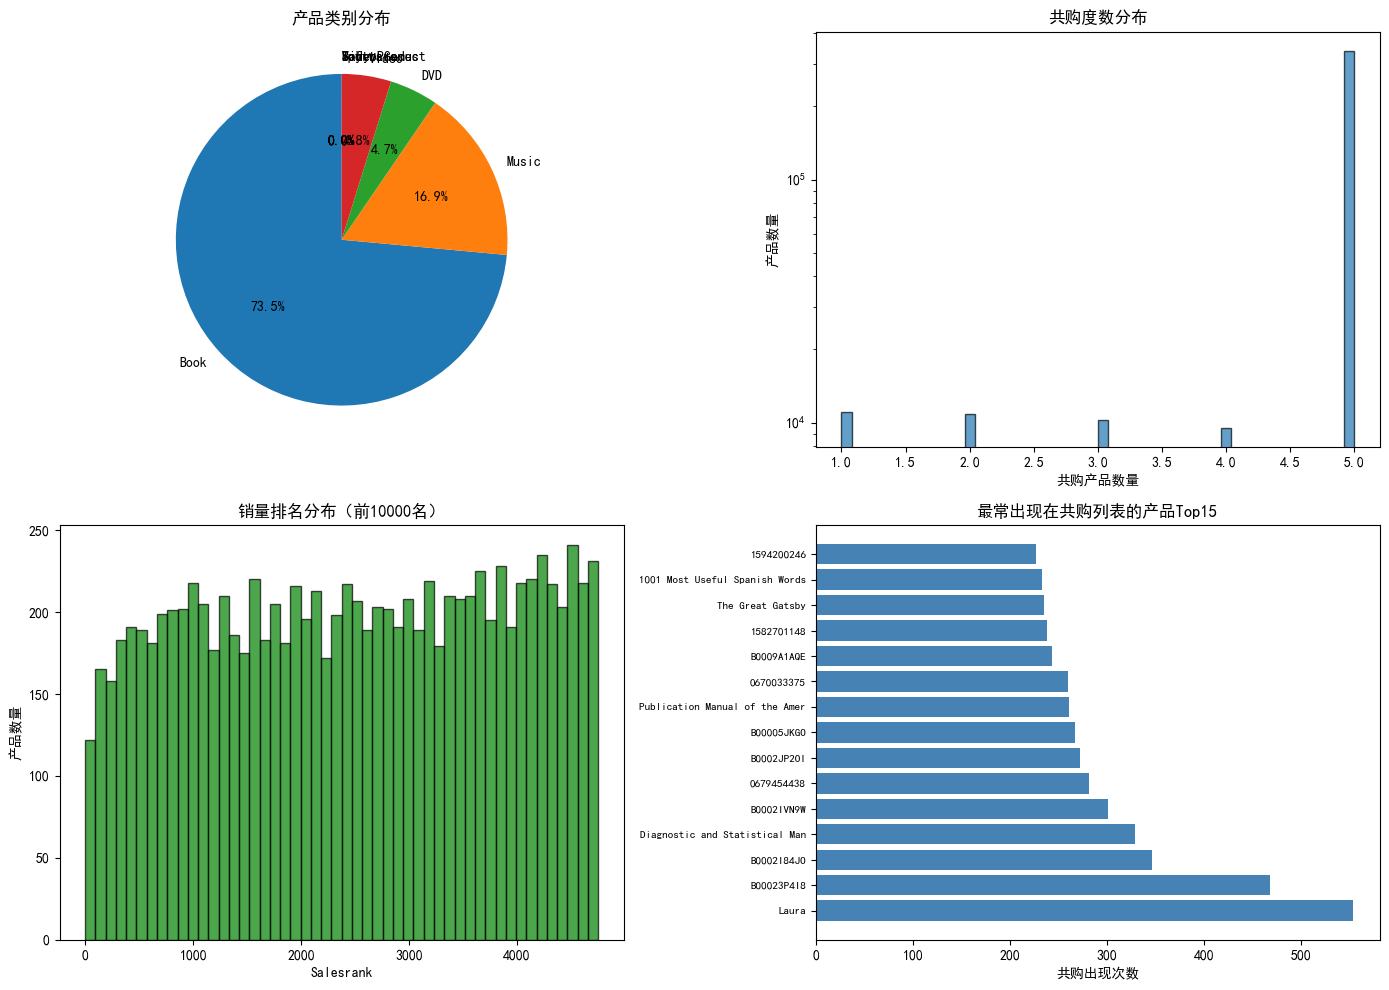


[3/4] 构建购物篮数据
原始产品数: 554789
过滤后产品数（共购关系≥3）: 419307
平均购物篮大小: 6.94
最大购物篮大小: 554

[4/4] 执行Apriori关联分析
总商品数: 543499


编码进度:   3%|▎         | 11801/419307 [18:50<10:50:51, 10.44it/s] 
Traceback (most recent call last):
  File "C:\Users\seama\AppData\Local\Temp\ipykernel_680\3905678325.py", line 523, in main
    df_encoded, frequent_items = encode_transactions(baskets, min_support_threshold=MIN_SUPPORT/2)
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\seama\AppData\Local\Temp\ipykernel_680\3905678325.py", line 304, in encode_transactions
    row = [1 if item in basket else 0 for item in all_products]
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\seama\AppData\Local\Temp\ipykernel_680\3905678325.py", line 304, in <listcomp>
    row = [1 if item in basket else 0 for item in all_products]
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
MemoryError



❌ 运行时错误: 


In [12]:
# ============================================
# Amazon真实数据集完整关联分析项目
# 适配SNAP Amazon Product Co-Purchasing Network Metadata
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from collections import Counter, defaultdict
import gzip
import re
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("="*70)
print("Amazon Product Co-Purchasing Network - 关联分析项目")
print("="*70)


# ============================================
# 第一部分：数据解析（直接从amazon-meta.txt.gz读取）
# ============================================

def parse_amazon_metadata(file_path, max_products=None):
    """
    解析SNAP Amazon元数据文件
    
    参数:
        file_path: amazon-meta.txt.gz 文件路径
        max_products: 最大解析产品数（用于测试，None表示全部）
    
    返回:
        transactions: 共购关系列表（每对产品作为一个"交易篮"）
        products_info: 产品元信息字典
    """
    print("\n[1/4] 正在解析Amazon元数据...")
    print(f"文件路径: {file_path}")
    
    transactions = []  # 存储共购关系对
    products_info = {}  # 存储产品元信息
    
    current_product = None
    current_asin = None
    current_group = None
    current_title = None
    current_salesrank = None
    similar_products = []
    
    open_func = gzip.open if file_path.endswith('.gz') else open
    
    with open_func(file_path, mode='rt', encoding='utf-8', errors='ignore') as f:
        for line_num, line in enumerate(tqdm(f, desc="解析进度")):
            if max_products and len(products_info) >= max_products:
                break
                
            line = line.strip()
            if not line:
                continue
            
            # 新产品的开始标志
            if line.startswith('Id:'):
                # 保存上一个产品的数据
                if current_product is not None and len(similar_products) > 0:
                    # 为每个共购产品创建一对
                    for sim_asin in similar_products:
                        if sim_asin and sim_asin != current_asin:
                            transactions.append([current_asin, sim_asin])
                    
                    # 保存产品元信息
                    products_info[current_asin] = {
                        'id': current_product,
                        'title': current_title,
                        'group': current_group,
                        'salesrank': current_salesrank,
                        'similar_count': len(similar_products)
                    }
                
                # 重置当前产品数据
                current_product = line.split(':')[1].strip()
                current_asin = None
                current_group = None
                current_title = None
                current_salesrank = None
                similar_products = []
            
            # 解析各字段
            elif line.startswith('ASIN:'):
                current_asin = line.split(':')[1].strip()
            
            elif line.startswith('title:'):
                current_title = line.replace('title:', '').strip()
                # 限制标题长度
                if len(current_title) > 100:
                    current_title = current_title[:97] + '...'
            
            elif line.startswith('group:'):
                current_group = line.split(':')[1].strip()
            
            elif line.startswith('salesrank:'):
                try:
                    current_salesrank = int(line.split(':')[1].strip())
                except:
                    current_salesrank = None
            
            elif line.startswith('similar:'):
                # 解析similar列表：格式如 "similar: 5 ASIN1 ASIN2 ASIN3 ..."
                sim_part = line.replace('similar:', '').strip()
                if sim_part:
                    parts = sim_part.split()
                    if len(parts) > 1:
                        # 第一个数字是计数，后面是ASIN列表
                        similar_products = parts[1:]  # 跳过计数
    
    # 保存最后一个产品
    if current_product is not None and len(similar_products) > 0 and current_asin:
        for sim_asin in similar_products:
            if sim_asin and sim_asin != current_asin:
                transactions.append([current_asin, sim_asin])
        products_info[current_asin] = {
            'id': current_product,
            'title': current_title,
            'group': current_group,
            'salesrank': current_salesrank,
            'similar_count': len(similar_products)
        }
    
    print(f"\n解析完成！")
    print(f"  产品总数: {len(products_info)}")
    print(f"  共购关系对数: {len(transactions)}")
    
    return transactions, products_info


# ============================================
# 第二部分：数据探索与产品信息统计
# ============================================

def explore_products(products_info, transactions):
    """分析产品元数据和网络结构"""
    print("\n" + "="*70)
    print("[2/4] 数据探索分析")
    print("="*70)
    
    # 1. 产品类别分布
    group_counts = defaultdict(int)
    salesranks = []
    similar_counts = []
    
    for asin, info in products_info.items():
        group = info.get('group', 'Unknown')
        group_counts[group] += 1
        if info.get('salesrank'):
            salesranks.append(info['salesrank'])
        similar_counts.append(info.get('similar_count', 0))
    
    print("\n📊 产品类别分布:")
    for group, count in sorted(group_counts.items(), key=lambda x: -x[1]):
        print(f"  {group}: {count:,} 个产品 ({count/len(products_info)*100:.1f}%)")
    
    # 2. 销量排名分析
    if salesranks:
        print(f"\n📈 销量排名统计 (Salesrank，数值越小越畅销):")
        print(f"  最低(最畅销): {min(salesranks):,}")
        print(f"  最高(最不畅销): {max(salesranks):,}")
        print(f"  中位数: {np.median(salesranks):,.0f}")
        
        # 畅销产品Top10
        top_selling = sorted(products_info.items(), key=lambda x: x[1].get('salesrank', 9999999))[:10]
        print(f"\n🌟 最畅销产品Top10:")
        for i, (asin, info) in enumerate(top_selling, 1):
            title = info.get('title', 'N/A')[:50]
            rank = info.get('salesrank', 'N/A')
            print(f"  {i}. [{rank}] {title}...")
    
    # 3. 共购网络统计
    unique_products_in_edges = set()
    for trans in transactions:
        unique_products_in_edges.update(trans)
    
    print(f"\n🔗 共购网络统计:")
    print(f"  参与共购的产品数: {len(unique_products_in_edges):,}")
    print(f"  总边数(共购关系): {len(transactions):,}")
    print(f"  平均每个产品的共购伙伴数: {np.mean(similar_counts):.2f}")
    print(f"  最大共购伙伴数: {max(similar_counts)}")
    
    # 4. 可视化
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 产品类别分布饼图
    groups = list(group_counts.keys())
    counts = list(group_counts.values())
    axes[0, 0].pie(counts, labels=groups, autopct='%1.1f%%', startangle=90)
    axes[0, 0].set_title('产品类别分布')
    
    # 共购度数分布直方图
    axes[0, 1].hist(similar_counts, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('共购产品数量')
    axes[0, 1].set_ylabel('产品数量')
    axes[0, 1].set_title('共购度数分布')
    axes[0, 1].set_yscale('log')
    
    # 销量排名分布（前10000）
    if salesranks:
        salesranks_sorted = sorted(salesranks)[:10000]
        axes[1, 0].hist(salesranks_sorted, bins=50, edgecolor='black', alpha=0.7, color='green')
        axes[1, 0].set_xlabel('Salesrank')
        axes[1, 0].set_ylabel('产品数量')
        axes[1, 0].set_title('销量排名分布（前10000名）')
    
    # 热门共购产品Top15
    product_degree = Counter()
    for trans in transactions:
        for product in trans:
            product_degree[product] += 1
    
    top_products = product_degree.most_common(15)
    prod_names = []
    prod_counts = []
    for asin, count in top_products:
        title = products_info.get(asin, {}).get('title', asin)[:30]
        prod_names.append(title)
        prod_counts.append(count)
    
    axes[1, 1].barh(range(len(prod_names)), prod_counts, color='steelblue')
    axes[1, 1].set_yticks(range(len(prod_names)))
    axes[1, 1].set_yticklabels(prod_names, fontsize=8)
    axes[1, 1].set_xlabel('共购出现次数')
    axes[1, 1].set_title('最常出现在共购列表的产品Top15')
    
    plt.tight_layout()
    plt.savefig('amazon_exploration.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return product_degree


# ============================================
# 第三部分：构建购物篮（适配关联分析格式）
# ============================================

def build_baskets(transactions, min_product_occurrence=5):
    """
    将共购关系转换为购物篮格式
    
    策略：将每个产品视为一个"用户"，其共购产品列表作为"购物篮"
    这样我们可以发现："买了A的用户，也会买B"
    """
    print("\n" + "="*70)
    print("[3/4] 构建购物篮数据")
    print("="*70)
    
    # 按产品聚合其共购伙伴
    product_baskets = defaultdict(set)
    for trans in transactions:
        if len(trans) == 2:
            a, b = trans
            product_baskets[a].add(b)
            product_baskets[b].add(a)
    
    # 过滤低频产品
    filtered_baskets = {}
    for product, basket in product_baskets.items():
        if len(basket) >= min_product_occurrence:
            filtered_baskets[product] = list(basket)
    
    print(f"原始产品数: {len(product_baskets)}")
    print(f"过滤后产品数（共购关系≥{min_product_occurrence}）: {len(filtered_baskets)}")
    
    # 统计购物篮大小
    basket_sizes = [len(b) for b in filtered_baskets.values()]
    print(f"平均购物篮大小: {np.mean(basket_sizes):.2f}")
    print(f"最大购物篮大小: {max(basket_sizes)}")
    
    return filtered_baskets


# ============================================
# 第四部分：One-Hot编码与Apriori挖掘
# ============================================

def encode_transactions(baskets, min_support_threshold=0.01):
    """将购物篮转换为One-Hot编码矩阵"""
    print("\n" + "="*70)
    print("[4/4] 执行Apriori关联分析")
    print("="*70)
    
    # 获取所有商品
    all_products = sorted(set([p for basket in baskets.values() for p in basket]))
    print(f"总商品数: {len(all_products)}")
    
    # 构建One-Hot矩阵
    encoded_data = []
    product_list = list(baskets.keys())
    
    for product in tqdm(product_list, desc="编码进度"):
        basket = set(baskets[product])
        row = [1 if item in basket else 0 for item in all_products]
        encoded_data.append(row)
    
    df_encoded = pd.DataFrame(encoded_data, columns=all_products, index=product_list)
    
    # 计算支持度并过滤低频商品
    item_support = df_encoded.mean(axis=0)
    frequent_items = item_support[item_support >= min_support_threshold].index.tolist()
    print(f"支持度阈值 {min_support_threshold} 下，保留商品数: {len(frequent_items)}/{len(all_products)}")
    
    df_filtered = df_encoded[frequent_items]
    
    return df_filtered, frequent_items


def mine_association_rules(df_encoded, min_support=0.03, min_confidence=0.3, min_lift=1.2):
    """挖掘频繁项集和关联规则"""
    
    # 挖掘频繁项集
    print(f"\n开始挖掘频繁项集 (min_support={min_support})...")
    frequent_itemsets = apriori(
        df_encoded, 
        min_support=min_support, 
        use_colnames=True,
        max_len=3  # 限制最大项集大小为3，提高可解释性
    )
    
    if len(frequent_itemsets) == 0:
        print("⚠️ 未找到频繁项集，请降低min_support阈值")
        return None, None
    
    frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
    print(f"找到 {len(frequent_itemsets)} 个频繁项集")
    print(f"  1-项集: {len(frequent_itemsets[frequent_itemsets['length']==1])}")
    print(f"  2-项集: {len(frequent_itemsets[frequent_itemsets['length']==2])}")
    print(f"  3-项集: {len(frequent_itemsets[frequent_itemsets['length']==3])}")
    
    # 生成关联规则
    print(f"\n生成关联规则 (min_confidence={min_confidence}, min_lift={min_lift})...")
    rules = association_rules(
        frequent_itemsets, 
        metric="confidence", 
        min_threshold=min_confidence
    )
    
    rules = rules[rules['lift'] >= min_lift]
    rules = rules.sort_values('lift', ascending=False)
    
    print(f"生成 {len(rules)} 条关联规则")
    
    return frequent_itemsets, rules


# ============================================
# 第五部分：结果可视化与业务解读
# ============================================

def visualize_results(rules, products_info, top_n=20):
    """可视化关联规则结果"""
    if rules is None or len(rules) == 0:
        print("没有足够的规则进行可视化")
        return
    
    print("\n" + "="*70)
    print("📊 关联规则分析结果")
    print("="*70)
    
    # 美化规则显示
    def format_rule(antecedents, consequents):
        def get_name(item):
            info = products_info.get(item, {})
            title = info.get('title', item)
            if len(title) > 25:
                title = title[:22] + '...'
            return title
        
        ante_str = ' + '.join([get_name(a) for a in antecedents][:2])
        cons_str = get_name(consequents)
        if len(antecedents) > 2:
            ante_str += '...'
        return f"{ante_str} → {cons_str}"
    
    # 显示Top规则
    print(f"\n🏆 提升度最高的{min(top_n, len(rules))}条关联规则:")
    print("-" * 80)
    
    for i, (idx, row) in enumerate(rules.head(top_n).iterrows(), 1):
        rule_desc = format_rule(row['antecedents'], row['consequents'])
        print(f"{i:2d}. {rule_desc}")
        print(f"    支持度: {row['support']:.4f} | 置信度: {row['confidence']:.3f} | 提升度: {row['lift']:.2f}")
    
    # 可视化
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 散点图：支持度 vs 置信度
    scatter = axes[0].scatter(
        rules['support'], 
        rules['confidence'], 
        c=rules['lift'], 
        cmap='RdYlGn', 
        alpha=0.6, 
        s=50
    )
    axes[0].set_xlabel('支持度 (Support)')
    axes[0].set_ylabel('置信度 (Confidence)')
    axes[0].set_title('规则质量分布（颜色=提升度）')
    plt.colorbar(scatter, ax=axes[0], label='提升度 (Lift)')
    axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    
    # Top规则柱状图
    top_lift_rules = rules.nlargest(min(15, len(rules)), 'lift')
    rule_names = [format_rule(row['antecedents'], row['consequents'])[:35] 
                  for _, row in top_lift_rules.iterrows()]
    
    colors = ['green' if l > 2 else 'orange' if l > 1.5 else 'blue' 
              for l in top_lift_rules['lift'].values]
    axes[1].barh(range(len(rule_names)), top_lift_rules['lift'].values, color=colors)
    axes[1].set_yticks(range(len(rule_names)))
    axes[1].set_yticklabels(rule_names, fontsize=8)
    axes[1].set_xlabel('提升度 (Lift)')
    axes[1].set_title('提升度最高的关联规则')
    axes[1].axvline(x=1, color='red', linestyle='--', alpha=0.7, label='基准线(Lift=1)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('amazon_association_rules.png', dpi=150, bbox_inches='tight')
    plt.show()


def generate_business_insights(rules, products_info):
    """生成业务洞察和建议"""
    if rules is None or len(rules) == 0:
        return
    
    print("\n" + "="*70)
    print("💡 业务洞察与建议")
    print("="*70)
    
    # 1. 强关联规则（提升度 > 3）
    strong_rules = rules[rules['lift'] > 3]
    if len(strong_rules) > 0:
        print(f"\n✅ 强关联规则（提升度>3，共{len(strong_rules)}条）:")
        for _, row in strong_rules.head(5).iterrows():
            ante = list(row['antecedents'])[0]
            cons = list(row['consequents'])[0]
            ante_title = products_info.get(ante, {}).get('title', ante)[:40]
            cons_title = products_info.get(cons, {}).get('title', cons)[:40]
            print(f"  • {ante_title}")
            print(f"    → {cons_title}")
            print(f"    (提升度: {row['lift']:.2f}，置信度: {row['confidence']:.1%})")
    
    # 2. 高置信度规则
    high_conf = rules[rules['confidence'] > 0.6].nlargest(5, 'confidence')
    if len(high_conf) > 0:
        print(f"\n🎯 高置信度规则（置信度>60%）:")
        for _, row in high_conf.iterrows():
            ante = list(row['antecedents'])[0]
            cons = list(row['consequents'])[0]
            ante_title = products_info.get(ante, {}).get('title', ante)[:40]
            cons_title = products_info.get(cons, {}).get('title', cons)[:40]
            print(f"  • 购买「{ante_title}」的用户")
            print(f"    有{row['confidence']:.1%}的概率也会购买「{cons_title}」")
    
    # 3. 业务建议
    print(f"\n📋 业务应用建议:")
    print("  1. 【交叉销售】将提升度>2.5的产品对在详情页互相推荐")
    print("  2. 【捆绑促销】将高置信度的产品对设计为套餐")
    print("  3. 【货架布局】将强关联产品放置在相邻位置")
    print("  4. 【个性化推荐】基于用户已购产品推荐高提升度关联品")
    
    # 4. 识别畅销品的关联模式
    print(f"\n⭐ 畅销产品关联分析:")
    # 找出salesrank最好（数值最小）的产品
    sorted_products = sorted(products_info.items(), key=lambda x: x[1].get('salesrank', 9999999))[:5]
    for asin, info in sorted_products:
        title = info.get('title', 'N/A')[:45]
        # 查找以该产品为antecedent的规则
        related_rules = rules[rules['antecedents'].apply(lambda x: asin in x)]
        if len(related_rules) > 0:
            top_rel = related_rules.nlargest(1, 'lift')
            cons = list(top_rel.iloc[0]['consequents'])[0]
            cons_title = products_info.get(cons, {}).get('title', cons)[:40]
            print(f"  • {title}")
            print(f"    → 关联推荐: {cons_title}")


# ============================================
# 主程序入口
# ============================================

def main():
    """主函数：执行完整分析流程"""
    
    # 配置参数
    DATA_PATH = "I:/app-data/amazon-meta.txt.gz"  # 请修改为实际文件路径
    MAX_PRODUCTS = None  # 测试时可限制解析产品数，完整分析设为None
    MIN_SUPPORT = 0.02    # 支持度阈值（根据数据规模调整）
    MIN_CONFIDENCE = 0.3  # 置信度阈值
    MIN_LIFT = 1.2        # 提升度阈值
    
    try:
        # 步骤1：解析原始数据
        transactions, products_info = parse_amazon_metadata(DATA_PATH, max_products=MAX_PRODUCTS)
        
        if len(transactions) == 0:
            print("错误：未解析到任何共购关系，请检查文件路径和格式")
            return
        
        # 步骤2：数据探索
        product_degree = explore_products(products_info, transactions)
        
        # 步骤3：构建购物篮
        baskets = build_baskets(transactions, min_product_occurrence=3)
        
        if len(baskets) < 10:
            print("错误：购物篮数量不足，请降低min_product_occurrence阈值")
            return
        
        # 步骤4：编码与关联挖掘
        df_encoded, frequent_items = encode_transactions(baskets, min_support_threshold=MIN_SUPPORT/2)
        
        if df_encoded.shape[1] < 5:
            print("错误：保留的商品数不足，请降低min_support_threshold")
            return
        
        frequent_itemsets, rules = mine_association_rules(
            df_encoded, 
            min_support=MIN_SUPPORT, 
            min_confidence=MIN_CONFIDENCE, 
            min_lift=MIN_LIFT
        )
        
        # 步骤5：可视化与业务洞察
        if rules is not None and len(rules) > 0:
            visualize_results(rules, products_info)
            generate_business_insights(rules, products_info)
            
            # 导出结果
            rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_csv(
                'amazon_association_rules.csv', index=False, encoding='utf-8-sig'
            )
            print(f"\n✅ 分析结果已导出到 amazon_association_rules.csv")
        else:
            print("\n⚠️ 未生成有效规则，建议:")
            print("   - 降低 min_support 阈值")
            print("   - 降低 min_confidence 阈值")
            print("   - 减小 min_lift 阈值")
            print("   - 增加 MAX_PRODUCTS 以获取更多数据")
    
    except FileNotFoundError:
        print(f"\n❌ 错误：找不到数据文件 {DATA_PATH}")
        print("\n请按以下步骤获取数据:")
        print("1. 访问 https://snap.stanford.edu/data/amazon-meta.html")
        print("2. 下载 amazon-meta.txt.gz (约2.8GB)")
        print("3. 将文件放在当前目录，或修改 DATA_PATH 变量")
    except Exception as e:
        print(f"\n❌ 运行时错误: {e}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()